# ApproxMC count distributions

A quick notebook to visualise the distributions of model counts obtained by ApproxMC with different seeds. This serves as a quick study into whether we might use a Kolmogorov-Smirnov test to see if the distribution is much different from what we expect based on the chosen tolerance $\epsilon$ and confidence $\delta$. 

We will use $c$ to denote the random variable that is the approximate model count obtained by ApproxMC. We will, for now, assume that the distribution will be a normal one, with mean $\mu_c = c^*$, where $c^*$ is the true count, and $\sigma_c = ?$. Maybe $\sigma_c = \epsilon \cdot c^*$, but we should dive into the exact mathematics of ApproxMC's approximation guarantees to come up with something more appropriate.

First, let us load the libraries:

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import resource
import seaborn as sns
import time
import subprocess
import sys
from collections import namedtuple
from functools import partial
from scipy.stats import kstest, norm

sys.path.append('../')
from fuzz import Solver

In [11]:
Options = namedtuple("Options", "epsilon delta maxtime maxtimediff verbose", defaults=[0.8, 0.1, 5, 3, False])
options = Options()

In [12]:
def setlimits(t):
    # Set maximum CPU time to 1 second in child process, after fork() but before exec()
    print("Setting resource limit in child (pid %d)" % os.getpid())
    resource.setrlimit(resource.RLIMIT_CPU, (t, t))
    
def run(command, dir):
    print("Executing: %s in dir %s" % (" ".join(command), dir))
    if options.verbose:
        print("CPU limit of parent (pid %d)" % os.getpid(), resource.getrlimit(resource.RLIMIT_CPU))

    p = subprocess.Popen(command, stderr=subprocess.STDOUT,
          stdout=subprocess.PIPE, universal_newlines=True, cwd=dir,
          preexec_fn=partial(setlimits, options.maxtime))

    consoleOutput, err = p.communicate()
    if options.verbose:
        print("CPU limit of parent (pid %d) after child finished executing" % os.getpid(),
            resource.getrlimit(resource.RLIMIT_CPU))
    return consoleOutput, err


def run_one_counter(solver, fname, seed=42):
    curr_time = time.time()
    toexec = solver.exe.split()
    toexec.append(os.getcwd() + "/" + fname)
    if not solver.exact:
        toexec.extend(["--epsilon", str(options.epsilon),
                       "--delta", str(options.delta),
                       "-s", str(seed)])
    out, err = run(toexec, solver.dir)
    if err is not None and err.strip() != "":
        print("Error string is: ", err)
    diff_time = time.time() - curr_time
    if diff_time > options.maxtime - options.maxtimediff:
        print("Too much time to solve with %s, aborted!" % solver.exe)
        return None

    num = None
    for l in out.split("\n"):
        l = l.strip()
        print(l)
        if len(l) < 4:
            continue
        if l[0] == 'c' and l[:3] != "c s":
            continue
        if l[:4] == "s mc" or l[:13] == "c s exact arb":
            if num is not None:
                print("ERROR: Two 's mc' lines in output!!")
                # TODO: print command that got executed
                exit(-1)
            if l[:4] == "s mc":
                num = int(l.split()[2])
            elif l[:13] == "c s exact arb":
                num = int(l.split()[5])
            else:
                print("ERROR")
                exit(-1)
    if num is None:
        print("ERROR, could not find 's mc' or 'c s exact arb int' in output")
        exit(-1)

    return num

We will use the CDFs, because that way we don't have to create a histogram, so we need a function to turn a list of counts into a CDF:

In [13]:
def ecdf(samples):
    """ From https://stackoverflow.com/questions/24788200/calculate-the-cumulative-distribution-function-cdf-in-python """
    x, counts = np.unique(samples, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

And we need a function to obtain the true count:

In [14]:
def get_true_count(cnf_file):
    solver = Solver("../../old_ganak/build/ganak", True)
    count = run_one_counter(solver, cnf_file.replace('sandbox/', ''))
    return count

We also need a function to read the stored counts from file:

In [15]:
def get_data(result_file):
    data = dict()
    with open(result_file, 'r') as f:
        data = json.load(f)
    seeds, counts = zip(*data['samples'])
    data['counts'] = counts
    data['true_count'] = get_true_count(data['fname2'])
    return data

We need a function to plot the histogram and some extra data:

In [16]:
def plot_hist_and_fit(data):
    # Fit a normal distribution to the data:
    mu, std = norm.fit(data['counts'])

    # Plot the histogram.
    plt.hist(data['counts'], bins=21, density=True, alpha=0.6, color='g')

    # Plot the PDF.
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2)
    
    # Plot the true count
    y = np.linspace(0, max(p)*1.5)
    x = [data['true_count']] * len(y)
    plt.plot(x, y, 'r', linewidth=2)

# mean_c = np.mean(counts)
# stdev_c = 0.1 * epsilon * mean_c / 1.65
# p = norm.pdf(x, mean_c, stdev_c)
# plt.plot(x, p, 'r', linewidth=2)

    title = "Fit: mu = %.0f, std = %.0f. True: c* = %.0f, stdc* = %.0f" % \
        (mu, std, data['true_count'], data['epsilon'] * data['true_count'] / 1.65)
    plt.title(title)

    plt.savefig(f"{data['fname2'].replace('sandbox/', '')}.{data['true_count']}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

If we use $\delta = 0.1$, this essentially means that we have a confidence interval of $90\%$. Hence, we could use $\sigma = \frac{\epsilon}{1.65} * \mu_c$ to obtain a best guess for the standard deviation of the distribution. However, this tends to be much larger than the standard deviation measured from the measured data. The next couple of plots show a histogram of the measured data, along with a fitted normal distribution and a vertical line to indicate the true count. In the title, I've added the fitted parameters (mu and std), and the true count (c*) and best guess for the std, computed as $\sigma = \frac{\epsilon}{1.65} * \mu_c$.

fuzzTest_138.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_138.cnf in dir None
Setting resource limit in child (pid 25677)
fuzzTest_138.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_138.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTION

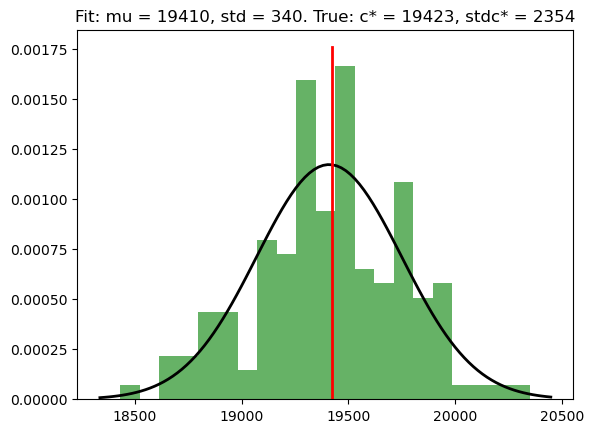

fuzzTest_110.cnf.2572796.pdf
fuzzTest_24.cnf
fuzzTest_107.cnf
fuzzTest_88.cnf.68777.pdf
fuzzTest_132.cnf.67116.pdf
fuzzTest_88.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_88.cnf in dir None
Setting resource limit in child (pid 25682)
fuzzTest_110.cnf.2572796.pdf
fuzzTest_24.cnf
fuzzTest_107.cnf
fuzzTest_88.cnf.68777.pdf
fuzzTest_132.cnf.67116.pdf
fuzzTest_88.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_88.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer

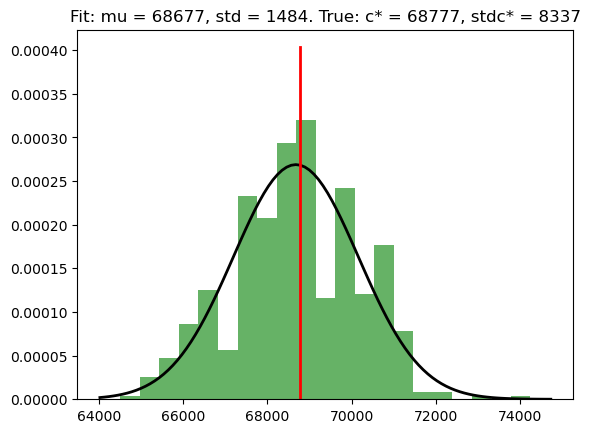

fuzzTest_189.cnf
fuzzTest_55.cnf
fuzzTest_110.cnf
fuzzTest_131.cnf
fuzzTest_106.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_106.cnf in dir None
Setting resource limit in child (pid 25687)
fuzzTest_189.cnf
fuzzTest_55.cnf
fuzzTest_110.cnf
fuzzTest_131.cnf
fuzzTest_106.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_106.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggd

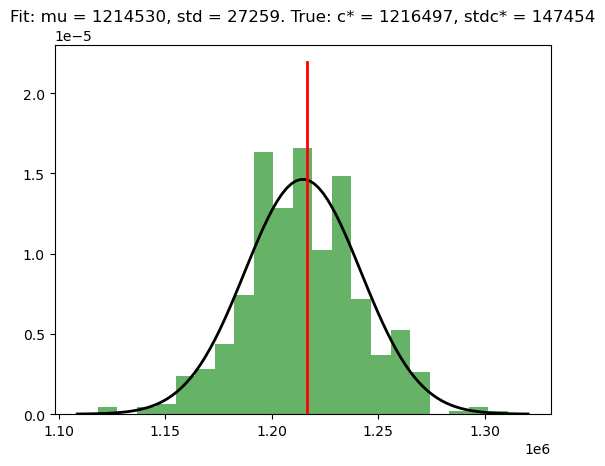

fuzzTest_52.cnf
fuzzTest_124.cnf.31149.pdf
fuzzTest_105.cnf
fuzzTest_51.cnf
fuzzTest_182.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_182.cnf in dir None
fuzzTest_52.cnf
fuzzTest_124.cnf.31149.pdf
fuzzTest_105.cnf
fuzzTest_51.cnf
fuzzTest_182.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_182.cnf in dir None
Setting resource limit in child (pid 25692)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunr

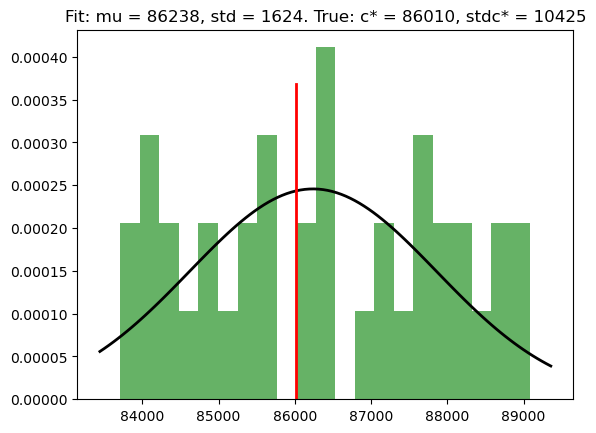

fuzzTest_137.cnf
fuzzTest_195.cnf
fuzzTest_196.cnf
fuzzTest_36.cnf.39079.pdf
fuzzTest_140.cnf
fuzzTest_36.cnf
fuzzTest_139.cnf
fuzzTest_24.cnf.1758.pdf
fuzzTest_28.cnf.24864.pdf
fuzzTest_36.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_36.cnf in dir None
Setting resource limit in child (pid 25697)
fuzzTest_137.cnf
fuzzTest_195.cnf
fuzzTest_196.cnf
fuzzTest_36.cnf.39079.pdf
fuzzTest_140.cnf
fuzzTest_36.cnf
fuzzTest_139.cnf
fuzzTest_24.cnf.1758.pdf
fuzzTest_28.cnf.24864.pdf
fuzzTest_36.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_36.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -We

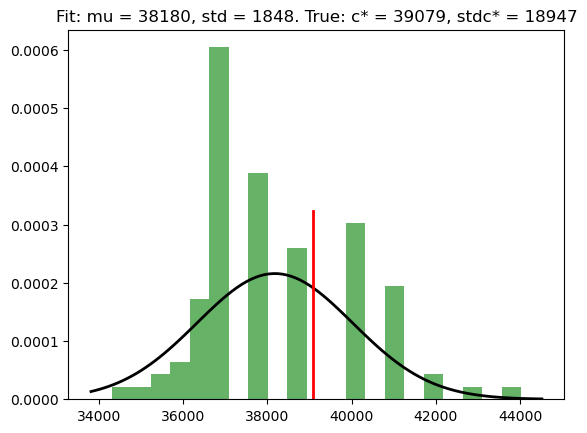

fuzzTest_138.cnf.19423.pdf
fuzzTest_52.cnf.18031.pdf
fuzzTest_132.cnf
fuzzTest_108.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_108.cnf in dir None
Setting resource limit in child (pid 25710)
fuzzTest_138.cnf.19423.pdf
fuzzTest_52.cnf.18031.pdf
fuzzTest_132.cnf
fuzzTest_108.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_108.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-cod

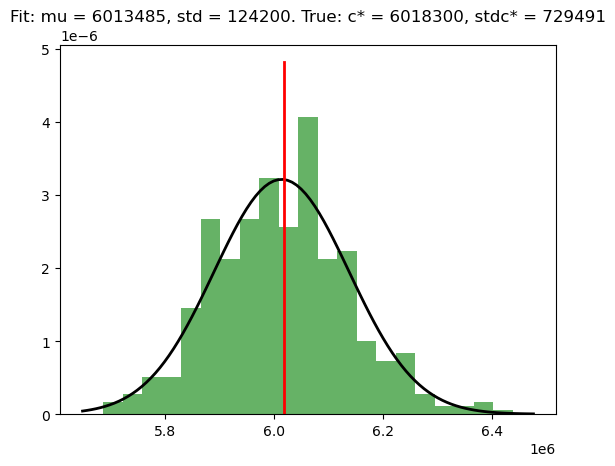

fuzzTest_106.cnf.1216497.pdf
fuzzTest_123.cnf
fuzzTest_88.cnf
fuzzTest_106.cnf
fuzzTest_24.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_24.cnf in dir None
Setting resource limit in child (pid 25715)
fuzzTest_106.cnf.1216497.pdf
fuzzTest_123.cnf
fuzzTest_88.cnf
fuzzTest_106.cnf
fuzzTest_24.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_24.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wu

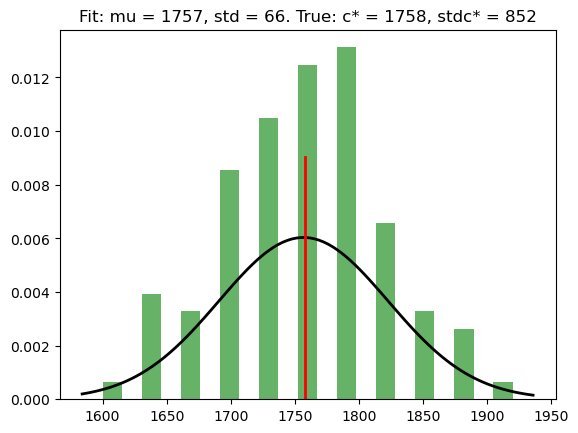

fuzzTest_124.cnf
fuzzTest_28.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_28.cnf in dir None
fuzzTest_124.cnf
fuzzTest_28.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_28.cnf in dir None
Setting resource limit in child (pid 25720)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE

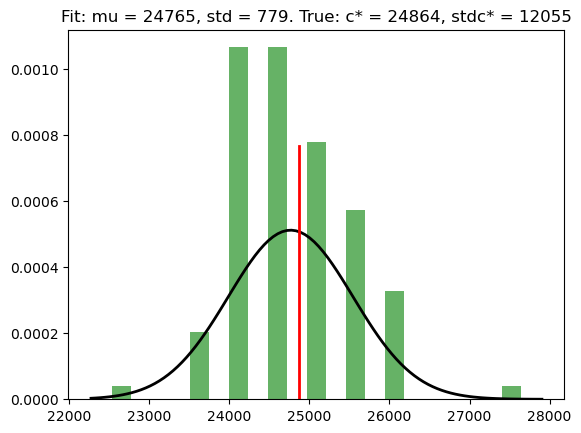

fuzzTest_28.cnf
fuzzTest_52.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_52.cnf in dir None
fuzzTest_28.cnf
fuzzTest_52.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_52.cnf in dir None
Setting resource limit in child (pid 25725)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_T

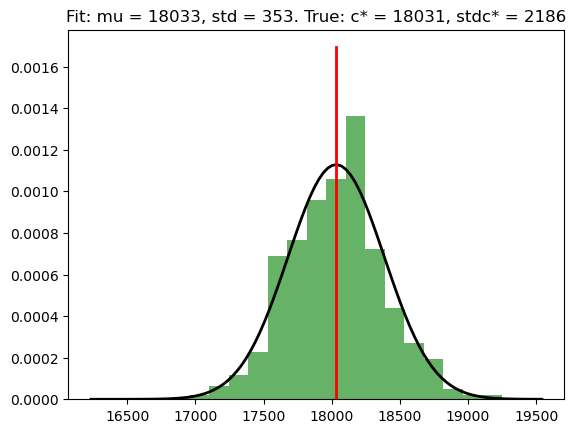

fuzzTest_138.cnf
fuzzTest_56.cnf.63987.pdf
fuzzTest_108.cnf.6018300.pdf
fuzzTest_124.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_124.cnf in dir None
Setting resource limit in child (pid 25730)
fuzzTest_138.cnf
fuzzTest_56.cnf.63987.pdf
fuzzTest_108.cnf.6018300.pdf
fuzzTest_124.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_124.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable

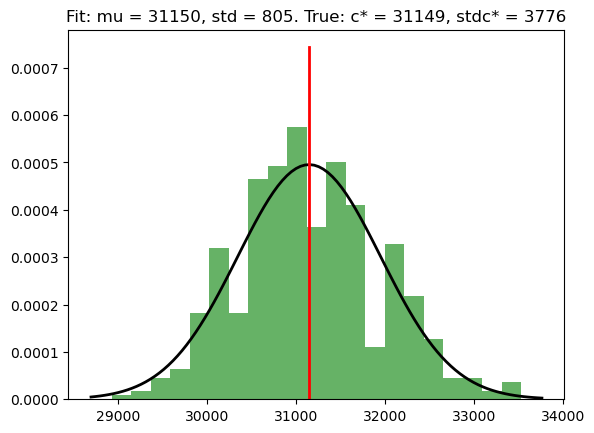

fuzzTest_132.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_132.cnf in dir None
fuzzTest_132.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_132.cnf in dir None
Setting resource limit in child (pid 25735)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTION

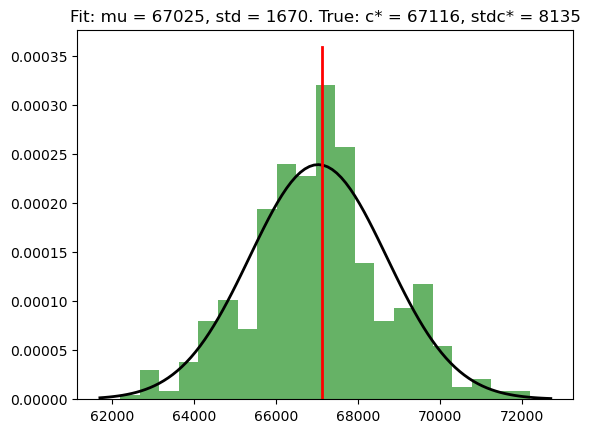

fuzzTest_58.cnf.68067.pdf
fuzzTest_87.cnf
fuzzTest_190.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_190.cnf in dir None
Setting resource limit in child (pid 25740)
fuzzTest_58.cnf.68067.pdf
fuzzTest_87.cnf
fuzzTest_190.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_190.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ON

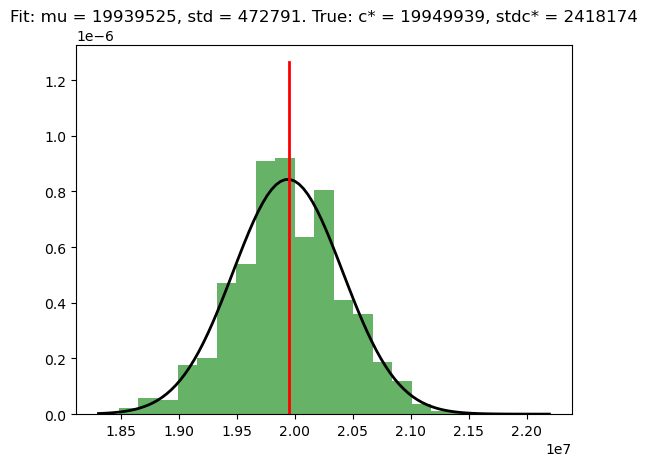

fuzzTest_44.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_44.cnf in dir None
fuzzTest_44.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_44.cnf in dir None
Setting resource limit in child (pid 25745)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = 

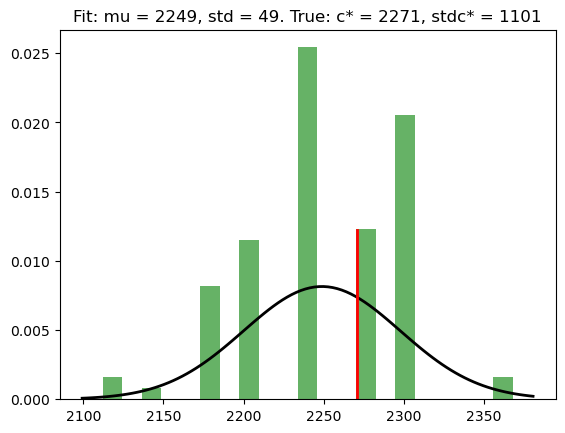

fuzzTest_58.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_58.cnf in dir None
fuzzTest_58.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_58.cnf in dir None
Setting resource limit in child (pid 25750)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_TESTING =  | ENABLE_ASSERTIONS = 

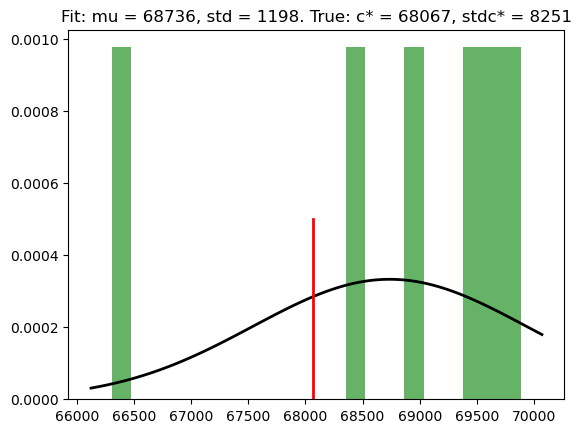

fuzzTest_181.cnf
fuzzTest_108.cnf
fuzzTest_109.cnf
fuzzTest_110.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_110.cnf in dir None
fuzzTest_181.cnf
fuzzTest_108.cnf
fuzzTest_109.cnf
fuzzTest_110.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_110.cnf in dir None
Setting resource limit in child (pid 25755)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATIC

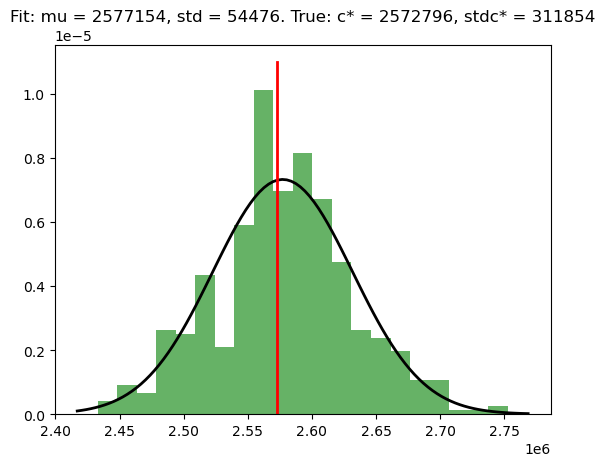

fuzzTest_57.cnf
fuzzTest_182.cnf
fuzzTest_140.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_140.cnf in dir None
Setting resource limit in child (pid 25760)
fuzzTest_57.cnf
fuzzTest_182.cnf
fuzzTest_140.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_140.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boo

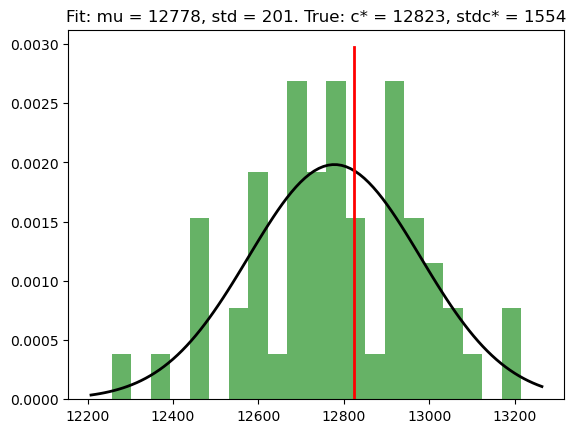

fuzzTest_58.cnf
fuzzTest_190.cnf
fuzzTest_196.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_196.cnf in dir None
Setting resource limit in child (pid 25765)
fuzzTest_58.cnf
fuzzTest_190.cnf
fuzzTest_196.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_196.cnf in dir None
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boo

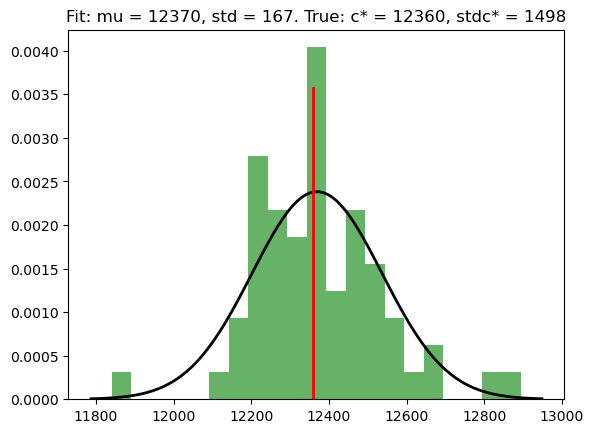

fuzzTest_56.cnf
fuzzTest_56.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_56.cnf in dir None
fuzzTest_56.cnf
fuzzTest_56.cnf.json
Executing: ../../old_ganak/build/ganak /home/soos/development/sat_solvers/count_fuzzer/sandbox/approxmc-results/nopreproc/fuzzTest_56.cnf in dir None
Setting resource limit in child (pid 25770)
c Setting the timout to: 100000
c Outputting solution to console
c GANAK version 1.0.0
c ganak GIT revision: d02ac9731d26755e4333e7cf0f66c51853cd05d5
c ganak build env: CMAKE_CXX_COMPILER = /usr/lib/ccache/bin/c++ | CMAKE_CXX_FLAGS =  -mtune=native -Wall -Wextra -Wunused -Wsign-compare -fno-omit-frame-pointer -Wtype-limits -Wuninitialized -Wno-deprecated -Wstrict-aliasing -Wpointer-arith -Wpointer-arith -Wformat-nonliteral -Winit-self -Wparentheses -Wunreachable-code -ggdb3 | COMPILE_DEFINES =  | STATICCOMPILE = OFF | ONLY_SIMPLE =  | Boost_FOUND =  | ZLIB_FOUND =  | ENABLE_T

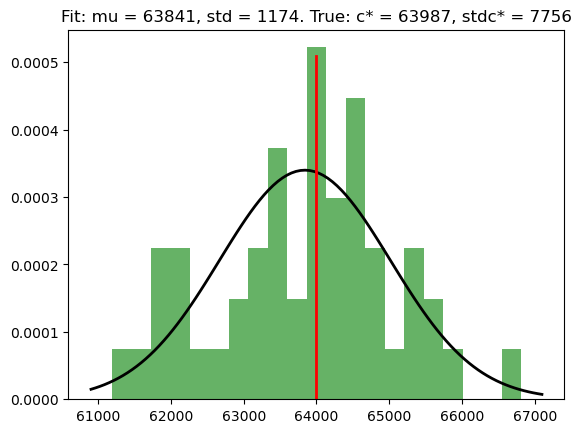

fuzzTest_44.cnf
fuzzTest_44.cnf.2271.pdf


<Figure size 640x480 with 0 Axes>

In [18]:
result_dir = 'approxmc-results/nopreproc/'
for result_file in os.listdir(result_dir):
    print(result_file)
    if not result_file.endswith('.json'):
        continue
    data = get_data(f"{result_dir}{result_file}")
    print(data)
    if np.mean(data['counts']) < 1000:
        continue
    plot_hist_and_fit(data)